In [1]:
library(did)
library(fixest)
library(dplyr)
library(readr)

panel <- read_csv("../data/clean/business_panel.csv")
head(panel)

Warning message:
“package ‘did’ was built under R version 4.5.2”
Warning message:
“package ‘fixest’ was built under R version 4.5.2”
Warning message:
“package ‘dplyr’ was built under R version 4.5.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘readr’ was built under R version 4.5.2”
Rows: 1204 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): branch_, radius_spec, year_quarter, treatment_quarter
dbl  (2): new_business_count, post
date (1): treatment_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


branch_,radius_spec,year_quarter,new_business_count,treatment_date,treatment_quarter,post
<chr>,<chr>,<chr>,<dbl>,<date>,<chr>,<dbl>
"Daley, Richard M.",0.25mi,2005Q1,1,2011-07-08,2011Q3,0
"Daley, Richard M.",0.25mi,2005Q2,6,2011-07-08,2011Q3,0
"Daley, Richard M.",0.25mi,2005Q3,4,2011-07-08,2011Q3,0
"Daley, Richard M.",0.25mi,2005Q4,1,2011-07-08,2011Q3,0
"Daley, Richard M.",0.25mi,2006Q1,5,2011-07-08,2011Q3,0
"Daley, Richard M.",0.25mi,2006Q2,5,2011-07-08,2011Q3,0


In [2]:
library(zoo)

panel <- panel %>%
  mutate(
    year_quarter_yq = as.yearqtr(year_quarter, format = "%YQ%q"),
    treatment_quarter_yq = as.yearqtr(treatment_quarter, format = "%YQ%q")
  )

head(panel)

Warning message:
“package ‘zoo’ was built under R version 4.5.1”

Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




branch_,radius_spec,year_quarter,new_business_count,treatment_date,treatment_quarter,post,year_quarter_yq,treatment_quarter_yq
<chr>,<chr>,<chr>,<dbl>,<date>,<chr>,<dbl>,<yearqtr>,<yearqtr>
"Daley, Richard M.",0.25mi,2005Q1,1,2011-07-08,2011Q3,0,2005 Q1,2011 Q3
"Daley, Richard M.",0.25mi,2005Q2,6,2011-07-08,2011Q3,0,2005 Q2,2011 Q3
"Daley, Richard M.",0.25mi,2005Q3,4,2011-07-08,2011Q3,0,2005 Q3,2011 Q3
"Daley, Richard M.",0.25mi,2005Q4,1,2011-07-08,2011Q3,0,2005 Q4,2011 Q3
"Daley, Richard M.",0.25mi,2006Q1,5,2011-07-08,2011Q3,0,2006 Q1,2011 Q3
"Daley, Richard M.",0.25mi,2006Q2,5,2011-07-08,2011Q3,0,2006 Q2,2011 Q3


In [5]:
panel <- panel %>%
  mutate(
    time_id = as.integer((year_quarter_yq - min(year_quarter_yq)) * 4) + 1,
    gvar_id = ifelse(
      is.na(treatment_quarter_yq),
      0,
      as.integer((treatment_quarter_yq - min(year_quarter_yq)) * 4) + 1
    )
  )

head(panel %>% select(branch_, radius_spec, year_quarter_yq, time_id, treatment_quarter_yq, gvar_id))

branch_,radius_spec,year_quarter_yq,time_id,treatment_quarter_yq,gvar_id
<chr>,<chr>,<yearqtr>,<dbl>,<yearqtr>,<dbl>
"Daley, Richard M.",0.25mi,2005 Q1,1,2011 Q3,27
"Daley, Richard M.",0.25mi,2005 Q2,2,2011 Q3,27
"Daley, Richard M.",0.25mi,2005 Q3,3,2011 Q3,27
"Daley, Richard M.",0.25mi,2005 Q4,4,2011 Q3,27
"Daley, Richard M.",0.25mi,2006 Q1,5,2011 Q3,27
"Daley, Richard M.",0.25mi,2006 Q2,6,2011 Q3,27


In [6]:
panel <- panel %>%
  mutate(panel_id = as.integer(factor(paste(branch_, radius_spec))))

In [7]:
head(panel %>% select(branch_, radius_spec, panel_id))

branch_,radius_spec,panel_id
<chr>,<chr>,<int>
"Daley, Richard M.",0.25mi,3
"Daley, Richard M.",0.25mi,3
"Daley, Richard M.",0.25mi,3
"Daley, Richard M.",0.25mi,3
"Daley, Richard M.",0.25mi,3
"Daley, Richard M.",0.25mi,3


In [9]:
att_result <- att_gt(
  yname = "new_business_count",
  tname = "time_id",
  idname = "panel_id",
  gname = "gvar_id",
  data = panel,
  panel = TRUE,
  allow_unbalanced_panel = FALSE,
  control_group = "notyettreated"
)

summary(att_result)

Warning message in did_standardization(data, args):
“Some groups in your dataset have very few observations, which may cause estimation problems.
  Check groups: 27,58,64.”
Warning message in att_gt(yname = "new_business_count", tname = "time_id", idname = "panel_id", :
“Not returning pre-test Wald statistic due to singular covariance matrix”



Call:
att_gt(yname = "new_business_count", tname = "time_id", idname = "panel_id", 
    gname = "gvar_id", data = panel, panel = TRUE, allow_unbalanced_panel = FALSE, 
    control_group = "notyettreated")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 

Group-Time Average Treatment Effects:
 Group Time ATT(g,t) Std. Error [95% Simult.  Conf. Band]  
    27    2   1.0000     3.0888       -7.5217      9.5217  
    27    3   1.9167     3.1814       -6.8606     10.6940  
    27    4  -4.7500     1.8224       -9.7778      0.2778  
    27    5   1.1667     1.0914       -1.8443      4.1777  
    27    6   3.6667     1.7709       -1.2191      8.5524  
    27    7  -5.8333     2.0180      -11.4008     -0.2659 *
    27    8   0.0833     2.4916       -6.7908      6.9575  
    27    9  -2.

In [10]:
agg_simple <- aggte(att_result, type = "simple")
summary(agg_simple)


Call:
aggte(MP = att_result, type = "simple")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 


    ATT    Std. Error     [ 95%  Conf. Int.] 
 0.1115        1.6855     -3.192       3.415 


---
Signif. codes: `*' confidence band does not cover 0

Control Group:  Not Yet Treated,  Anticipation Periods:  0
Estimation Method:  Doubly Robust


In [11]:
agg_dynamic <- aggte(att_result, type = "dynamic")
summary(agg_dynamic)


Call:
aggte(MP = att_result, type = "dynamic")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 


Overall summary of ATT's based on event-study/dynamic aggregation:  
     ATT    Std. Error     [ 95%  Conf. Int.] 
 -0.0559        1.7613    -3.5079      3.3962 


Dynamic Effects:
 Event time Estimate Std. Error [95% Simult.  Conf. Band]  
        -56  -7.1667     2.8622      -14.7955      0.4622  
        -55   6.7667     4.0664       -4.0718     17.6051  
        -54  -9.2000     3.9833      -19.8167      1.4167  
        -53   3.8333     2.1004       -1.7648      9.4315  
        -52   1.0833     1.2952       -2.3688      4.5355  
        -51  -0.3167     1.5551       -4.4615      3.8281  
        -50   1.4167     1.9686       -3.8302      6.6635  
        -49   1.4667     2.99

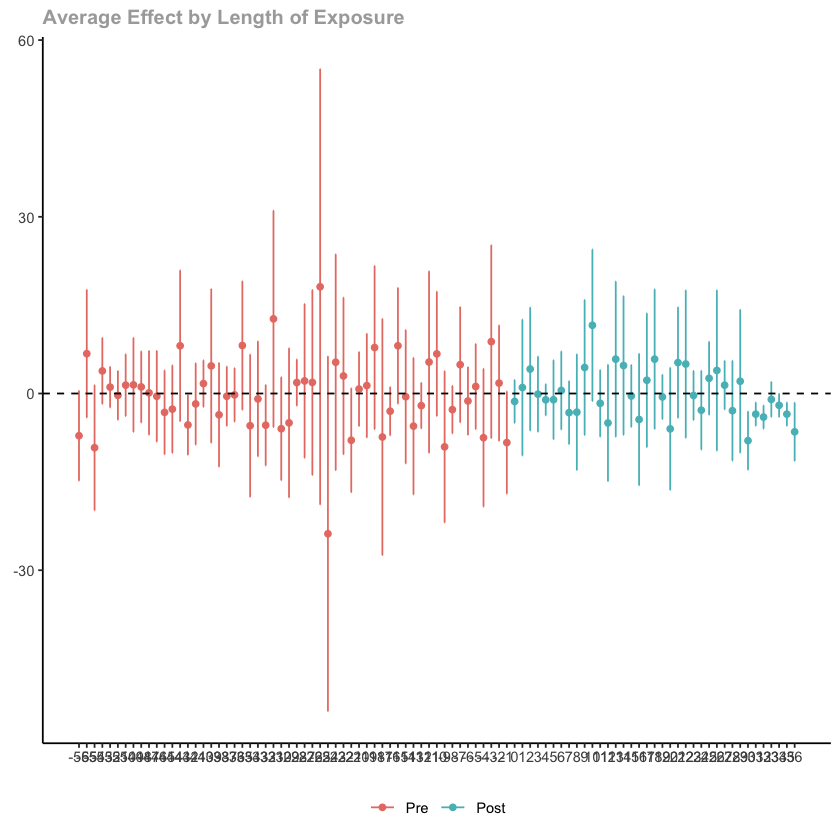

In [12]:
ggdid(agg_dynamic)


Call:
aggte(MP = att_result, type = "dynamic", min_e = -8, max_e = 8)

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 


Overall summary of ATT's based on event-study/dynamic aggregation:  
     ATT    Std. Error     [ 95%  Conf. Int.] 
 -0.4796        1.5288    -3.4761      2.5168 


Dynamic Effects:
 Event time Estimate Std. Error [95% Simult.  Conf. Band] 
         -8  -2.7361     1.4634       -6.2801      0.8079 
         -7   4.8944     3.7351       -4.1511     13.9400 
         -6  -1.2722     2.1908       -6.5779      4.0335 
         -5   1.1861     2.7887       -5.5675      7.9397 
         -4  -7.5000     4.2151      -17.7082      2.7082 
         -3   8.8028     6.1245       -6.0294     23.6349 
         -2   1.7667     3.8342       -7.5189     11.0523 
         -1  -

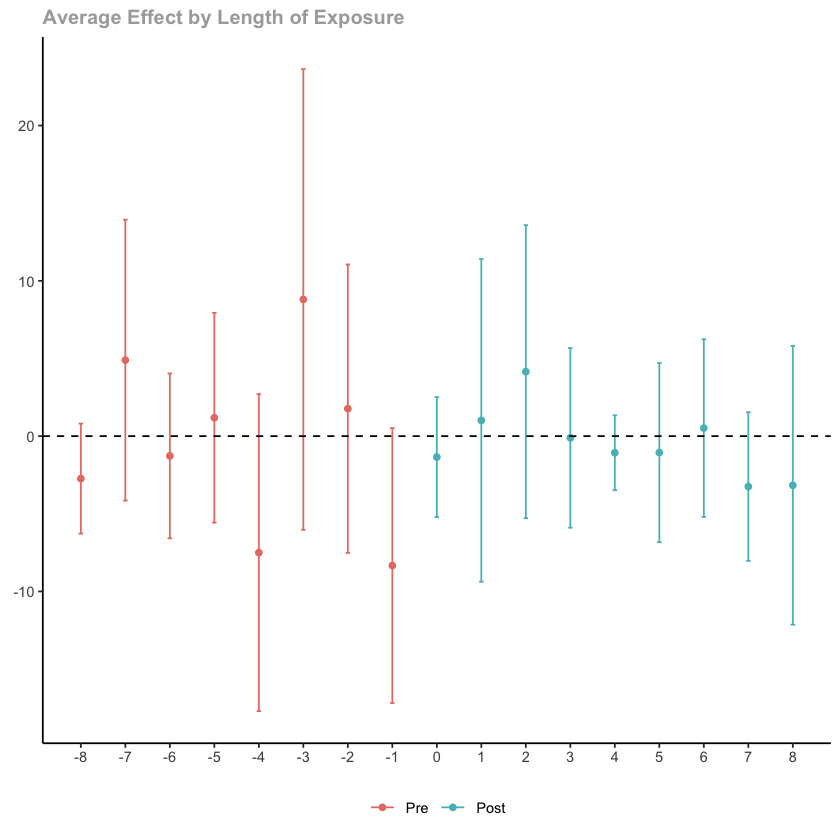

In [13]:
agg_dynamic <- aggte(att_result, type = "dynamic", min_e = -8, max_e = 8)
summary(agg_dynamic)
ggdid(agg_dynamic)

In [15]:
library(ggplot2)
ggsave("../output/figures/event_study_R_crosscheck.png", width = 10, height = 6, dpi = 300)

In [16]:
# Cross-check summary:
# Stata (csdid):  ATT = 0.118, SE = 1.35, p = 0.931
# R (did):        ATT = 0.112, SE = 1.69, CI spans 0 comfortably
# Conclusion: independently replicated null result across two
# separate software implementations of Callaway & Sant'Anna (2021).